In [ ]:
import sys

import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt

from math import ceil
from pathlib import Path
from IPython.display import display

ROOT_DIR = Path().resolve().parents[0]
sys.path.insert(0, str(ROOT_DIR))

from bout_dump import BOUTHESELInfo
from bout_phys import BOUTHESELPhys

root = ROOT_DIR / r"sim_data/Alexander_pi"
info = BOUTHESELInfo(root)
phys = BOUTHESELPhys(info)

In [15]:
# for (section, name), value in info.settings.items():
#     print(f'{section},{name} = {value}')

# for field, value in info.data.__dict__.items():
#     print(f'{field} = {value.shape}')

# for field, value in info.parameters.__dict__.items():
#     print(f'{field} = {value}')

# for name, foo in info.functions.__dict__.items():
#     print(f'{name} = {foo}')

3D fields: ['lnn', 'lnpe', 'lnpi', 'phi', 'vort']
2D fields: ['init_n', 'init_pe', 'init_pi', 'sigma_open', 'sigma_closed', 'sigma_force', 'B', 'dx', 'lconn']
Skipped scalar fields: ['dz', 'Bt', 'q', 'Te0', 'Ti0', 'n0', 'Rmajor', 'Rminor', 'A', 'Z', 'Mach', 'x_lcfs', 'x_wall', 'force_time', 'floor_time', 'floor_n', 'floor_pe', 'floor_pi', 'B0', 'oci', 'rhoe', 'rhos', 'nuei', 'nuii', 'nuee', 'neoclass_correction_factor', 'lblob']


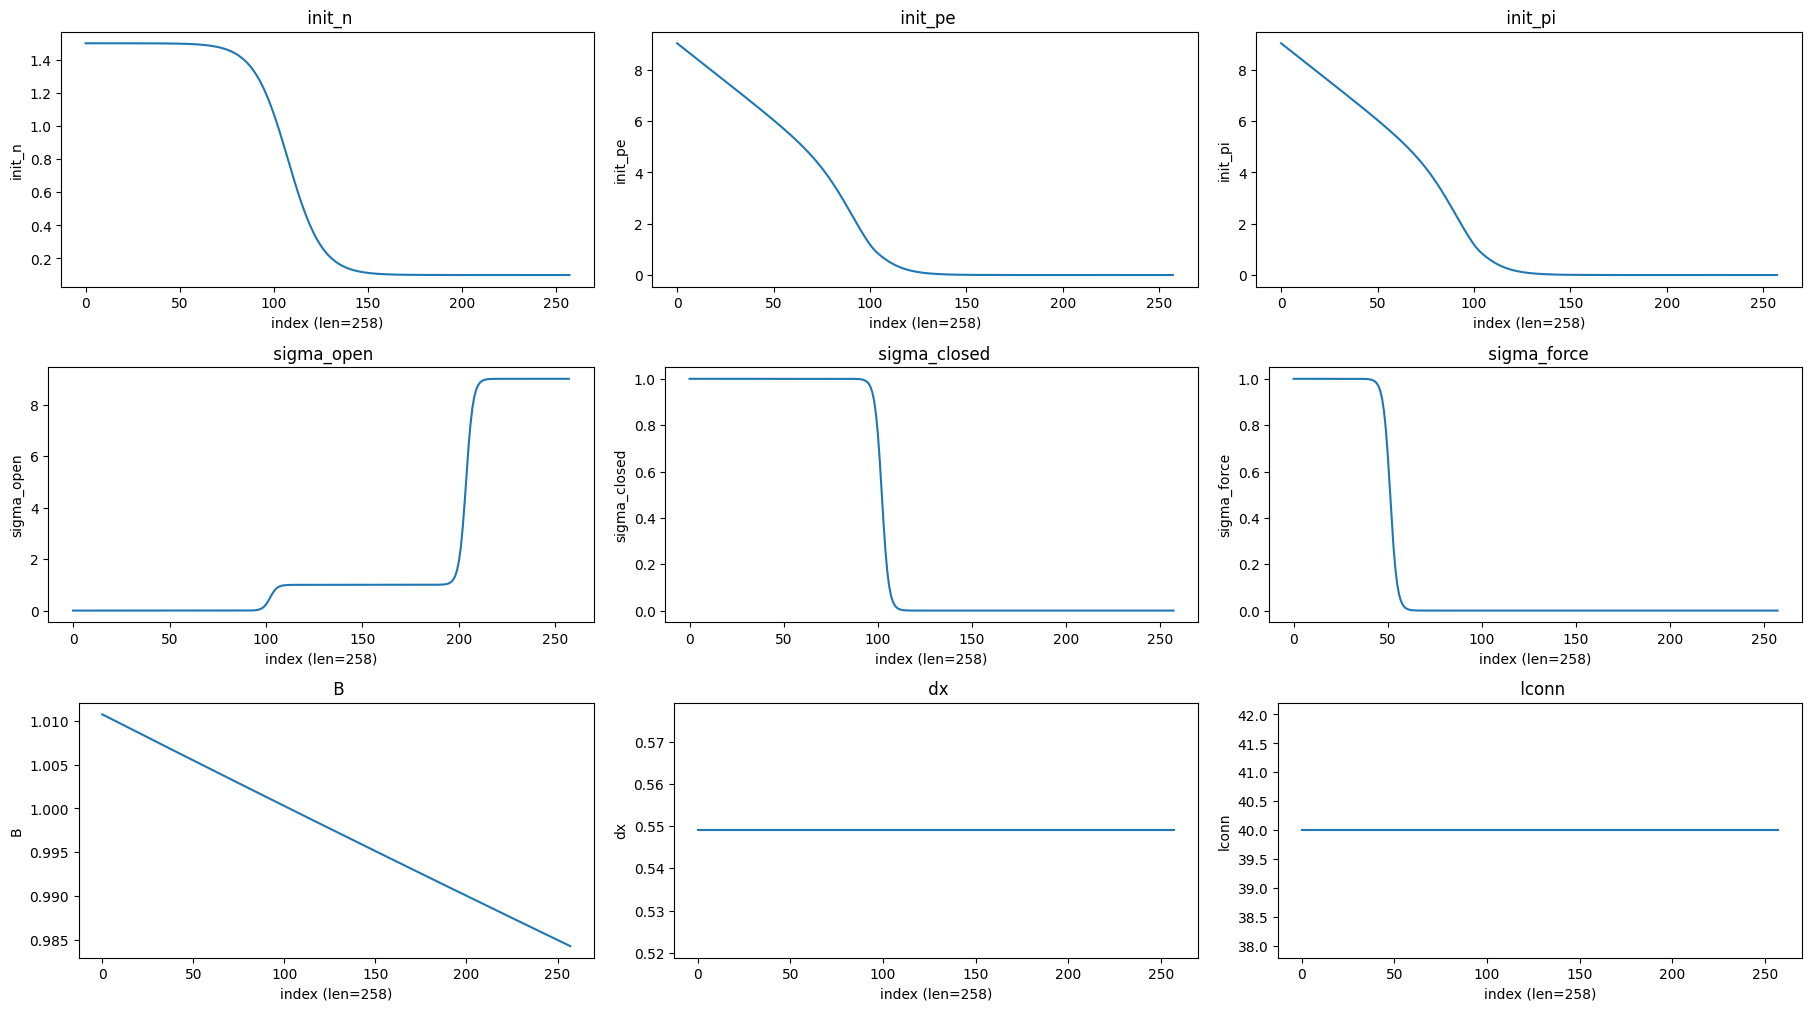

In [ ]:
three_d_fields = []
two_d_fields = []
scalar_fields = []
time_array = info.data.t_array.detach().cpu().numpy()
for name, arr in info.data.__dict__.items():
    if arr is None or name == 't_array':
        continue
    if arr.ndim == 3:
        three_d_fields.append((name, arr))
    elif arr.ndim == 1:
        two_d_fields.append((name, arr))
    elif arr.ndim == 0:
        scalar_fields.append(name)

print('3D fields:', [name for name, _ in three_d_fields])
print('2D fields:', [name for name, _ in two_d_fields])
print('Skipped scalar fields:', scalar_fields)

def make_grid(n_items, ncols):
    return ceil(n_items / ncols), ncols

def axis_label(name, length):
    return f'{name} (len={length})'

def plot_3d_frame(time_index):
    time_value = float(time_array[time_index])
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    nrows, ncols = make_grid(len(three_d_fields), 3)
    subfigs = np.asarray(fig.subfigures(nrows, ncols, squeeze=False)).ravel()

    for slot, (name, arr) in enumerate(three_d_fields):
        subfig = subfigs[slot]
        ax = subfig.subplots()
        frame = arr[time_index].detach().cpu().numpy().T
        im = ax.imshow(frame, cmap='viridis', interpolation='nearest', vmin=float(arr.min().item()), vmax=float(arr.max().item()))
        ax.set_title(f'{name} @ t={time_value:.4g}')
        ax.set_xlabel(axis_label('x', arr.shape[1]))
        ax.set_ylabel(axis_label('z', arr.shape[2]))
        fig.colorbar(im, ax=ax, shrink=0.8)

    for subfig in subfigs[len(three_d_fields):]:
        subfig.set_visible(False)

    return fig

def plot_two_d_fields():
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    nrows, ncols = make_grid(len(two_d_fields), 3)
    subfigs = np.asarray(fig.subfigures(nrows, ncols, squeeze=False)).ravel()

    for slot, (name, arr) in enumerate(two_d_fields):
        subfig = subfigs[slot]
        ax = subfig.subplots()
        values = arr.detach().cpu().numpy()
        ax.plot(np.arange(values.shape[0]), values, linewidth=1.5)
        ax.set_title(f" {name}")
        ax.set_xlabel(axis_label('index', values.shape[0]))
        ax.set_ylabel(name)

    for subfig in subfigs[len(two_d_fields):]:
        subfig.set_visible(False)

    return fig


output_3d = widgets.Output()
slider = widgets.IntSlider(
    min=0,
    max=len(time_array) - 1,
    step=1,
    value=0,
    description='t',
    continuous_update=False,
)

def render_3d(_change=None):
    _ = _change
    with output_3d:
        output_3d.clear_output(wait=True)
        fig = plot_3d_frame(slider.value)
        display(fig)
        plt.close(fig)

slider.observe(render_3d, names='value')
render_3d()
display(widgets.VBox([slider, output_3d]))

fig = None
if two_d_fields:
    fig = plot_two_d_fields()
    display(fig)
if fig is not None:
    plt.close(fig)